# Stroke Prediction — Data Cleaning & Preprocessing
### ITAI 1371 Midterm — Team ML_1371_12321 (Edwin, Kala, Anashrah, Zain)

**Dataset:** Stroke Prediction Dataset (Kaggle, fedesoriano) — 5,110 rows × 12 columns
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

**Goal of this notebook:** take the raw dataset and produce a clean, balanced training set ready for model building, while keeping the test set untouched so our future evaluation is honest.

**The golden rule we follow throughout:**
> Split FIRST → do everything else on training only → SMOTE-balance LAST. The test set is set aside immediately after the split and never sees imputation values, scaler ranges, or SMOTE derived from itself. Touching the test set corrupts the experiment.

**Pipeline order (this order matters):**
1. Load data, drop the `id` column
2. **Stratified 70/30 split** (test set set aside now)
3. **EDA on training data only** (Mr. Rao's requirement)
4. Impute missing `bmi` (median) — fit on train
5. One-hot encode categoricals + scale numerics — fit on train
6. **SMOTE on the training set only** — before/after plot
7. Save the clean balanced dataset

## 0. Setup

`SMOTE` lives in the `imbalanced-learn` library, which is **not** part of base scikit-learn, so we install it first. On Google Colab this cell needs to run once per session.

In [ ]:
# Install imbalanced-learn (provides SMOTE). Safe to re-run.
!pip install imbalanced-learn -q

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (1).csv


In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# SMOTE for class balancing (training data only)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42   # fixed seed so results are reproducible for everyone on the team
pd.set_option("display.max_columns", None)
print("Libraries loaded.")

Libraries loaded.


## 1. Load the raw data

The raw CSV records missing BMI values as the string `"N/A"`, so we tell pandas to read those as real missing values (`NaN`). We also drop `id`, which is just a row number and carries no predictive information.

In [ ]:
# >>> If your file is named differently or lives in a different folder, change this line only. <<<
CSV_PATH = "healthcare-dataset-stroke-data.csv"

# na_values="N/A" makes pandas treat the literal string "N/A" as a missing value
df = pd.read_csv(CSV_PATH, na_values="N/A")

print("Raw shape:", df.shape)   # expected: (5110, 12)
df.head()

Raw shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# Structure and data types of every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Drop the id column — it's just an identifier, not a feature
df = df.drop(columns=["id"])
print("Shape after dropping id:", df.shape)
df.head()

Shape after dropping id: (5110, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Split FIRST — 70% train / 30% test (stratified)

This is the most important step for avoiding data leakage. We split **before** any cleaning, imputation, scaling, or balancing.

- `stratify=y` keeps the real stroke ratio (~5%) in *both* the training and test sets, so the test set still looks like the real world.
- After this cell, `X_test` / `y_test` are **set aside and never touched again** until the finals.

In [ ]:
# Separate features (X) from the target we want to predict (y = stroke)
X = df.drop(columns=["stroke"])
y = df["stroke"]

# 70/30 split, stratified on the target so both sides keep the ~5% stroke rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print()
print("Stroke rate in TRAIN: {:.2f}%".format(100 * y_train.mean()))
print("Stroke rate in TEST:  {:.2f}%".format(100 * y_test.mean()))
print("(Both should be ~5% — that confirms the stratified split worked.)")

Training set: (3577, 10)
Test set:     (1533, 10)

Stroke rate in TRAIN: 4.86%
Stroke rate in TEST:  4.89%
(Both should be ~5% — that confirms the stratified split worked.)


## 3. Exploratory Data Analysis — **training data only**

Per the assignment, EDA is performed **only** on the training data. The test set stays sealed. Everything below uses `X_train` / `y_train`.

In [ ]:
# Summary statistics of the numeric features (training only)
X_train.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi
count,3577.000000,3577.000000,3577.000000,3577.000000,3429.000000
mean,43.250433,0.096170,0.053956,105.957414,28.867279
std,22.493077,0.294865,0.225962,44.945203,7.909601
min,0.080000,0.000000,0.000000,55.120000,10.300000
25%,26.000000,0.000000,0.000000,77.460000,23.500000
50%,45.000000,0.000000,0.000000,91.710000,28.000000
75%,61.000000,0.000000,0.000000,113.630000,33.100000
max,82.000000,1.000000,1.000000,271.740000,92.000000


In [ ]:
# How many missing values does each training column have?
# bmi is the one with missing entries.
print("Missing values per column (training set):")
print(X_train.isna().sum())

Missing values per column (training set):
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  148
smoking_status         0
dtype: int64


### 3a. The class imbalance problem (BEFORE balancing)

This is the core reason we need SMOTE. The chart below shows how lopsided the target is.

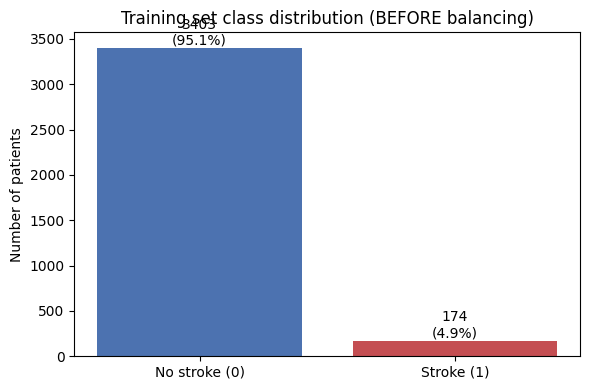

This is heavily imbalanced (~95% / ~5%). A model trained on this as-is
could predict 'no stroke' every time and still look ~95% accurate — while
catching zero actual strokes. That is why we balance the training data.


In [ ]:
# Bar chart of the target classes in the training set
counts = y_train.value_counts().sort_index()
labels = ["No stroke (0)", "Stroke (1)"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, counts.values, color=["#4c72b0", "#c44e52"])
plt.title("Training set class distribution (BEFORE balancing)")
plt.ylabel("Number of patients")
for bar, val in zip(bars, counts.values):
    pct = 100 * val / counts.sum()
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val}\n({pct:.1f}%)",
             ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("This is heavily imbalanced (~95% / ~5%). A model trained on this as-is")
print("could predict 'no stroke' every time and still look ~95% accurate — while")
print("catching zero actual strokes. That is why we balance the training data.")

### 3b. Distributions of the numeric features

Histograms of the three continuous features help us understand ranges and spot skew (useful context for why we scale later).

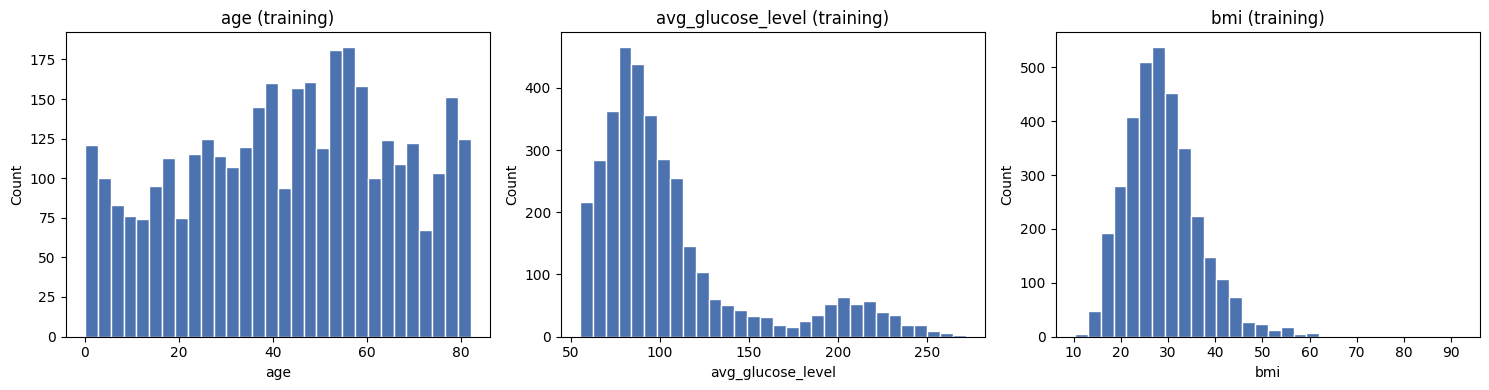

In [ ]:
# Histograms of the continuous numeric features (training only)
num_features = ["age", "avg_glucose_level", "bmi"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_features):
    ax.hist(X_train[col].dropna(), bins=30, color="#4c72b0", edgecolor="white")
    ax.set_title(f"{col} (training)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 4. Preprocessing — fit on TRAIN, apply to both

Now we clean the data. Two rules keep us honest:

1. Everything we *learn* (the median BMI, the encoder's categories, the scaler's ranges) is learned **from the training set only** (`fit`), then merely **applied** to the test set (`transform`). We never fit on the test set.
2. This all happens **before** SMOTE, because SMOTE needs (a) no missing values and (b) all-numeric input — it creates synthetic rows by interpolating between numbers.

We use a `ColumnTransformer` so numeric and categorical columns get the right treatment automatically:
- **Numeric** (`age`, `avg_glucose_level`, `bmi`): median imputation → standard scaling
- **Categorical** (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`): one-hot encoding
- **Already 0/1** (`hypertension`, `heart_disease`): passed through unchanged

In [ ]:
# Group the columns by how they should be treated
numeric_cols     = ["age", "avg_glucose_level", "bmi"]
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
# hypertension and heart_disease are already 0/1 -> handled by remainder="passthrough"

# Numeric branch: fill missing bmi with the (training) median, then scale
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler())
])

# Combine both branches
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="passthrough"   # keeps hypertension & heart_disease as-is
)

# FIT on training data, then TRANSFORM both sets.
X_train_processed = preprocessor.fit_transform(X_train)   # fit + transform (train)
X_test_processed  = preprocessor.transform(X_test)        # transform ONLY (test) — no leakage

# Recover readable column names for the new all-numeric matrix
feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:    ", X_test_processed.shape)
print("Missing values left? train:", np.isnan(X_train_processed).any(),
      "| test:", np.isnan(X_test_processed).any(), "(both should be False)")

Processed training shape: (3577, 21)
Processed test shape:     (1533, 21)
Missing values left? train: False | test: False (both should be False)


In [ ]:
# Print a sample of the processed training data so we can see what the model will receive
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
print("Sample of processed training data (first 5 rows):")
X_train_processed_df.head()

Sample of processed training data (first 5 rows):


,num__age,num__avg_glucose_level,num__bmi,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__ever_married_No,cat__ever_married_Yes,cat__work_type_Govt_job,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Rural,cat__Residence_type_Urban,cat__smoking_status_Unknown,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes,remainder__hypertension,remainder__heart_disease
0,0.389044,0.041892,-0.882035,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.833687,-0.392475,0.964308,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.678510,-0.232925,0.073415,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.522437,-0.720699,-0.107346,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.277921,-0.051123,0.938485,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Class balancing with SMOTE — **training set only**

SMOTE (Synthetic Minority Over-sampling Technique) creates new synthetic stroke rows by interpolating between real stroke patients that are near each other in feature space. This lifts the minority class up to match the majority.

**We apply it ONLY to the training set.** The test set keeps the real-world ~5% rate so that when we evaluate models in the finals, the numbers reflect reality.

In [ ]:
# Class counts BEFORE SMOTE (training)
before_counts = pd.Series(y_train).value_counts().sort_index()
print("Training class counts BEFORE SMOTE:")
print(before_counts.to_string())

# Apply SMOTE to the PROCESSED TRAINING data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

# Class counts AFTER SMOTE
after_counts = pd.Series(y_train_balanced).value_counts().sort_index()
print("\nTraining class counts AFTER SMOTE:")
print(after_counts.to_string())
print("\nBalanced training shape:", X_train_balanced.shape)
print("Test set is unchanged:", X_test_processed.shape, "(never SMOTE'd)")

Training class counts BEFORE SMOTE:
stroke
0    3403
1     174

Training class counts AFTER SMOTE:
stroke
0    3403
1    3403

Balanced training shape: (6806, 21)
Test set is unchanged: (1533, 21) (never SMOTE'd)


### 5a. Before vs after — the balancing, visualized

This side-by-side chart is the "before and after" that the assignment asks us to show with Matplotlib.

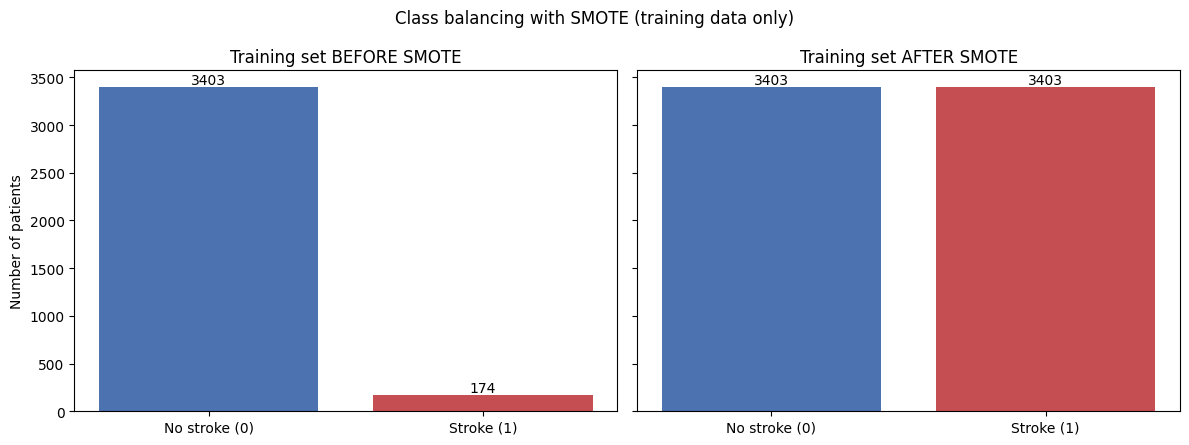

In [ ]:
# Side-by-side before/after bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
labels = ["No stroke (0)", "Stroke (1)"]

axes[0].bar(labels, before_counts.values, color=["#4c72b0", "#c44e52"])
axes[0].set_title("Training set BEFORE SMOTE")
axes[0].set_ylabel("Number of patients")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

axes[1].bar(labels, after_counts.values, color=["#4c72b0", "#c44e52"])
axes[1].set_title("Training set AFTER SMOTE")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.suptitle("Class balancing with SMOTE (training data only)")
plt.tight_layout()
plt.show()

## 6. Save the clean dataset

We save the **balanced, fully-processed training set** as our clean deliverable. We also save the processed (but *not* SMOTE'd) test set so it's ready for the finals — clearly separated so the two never get mixed up.

In [ ]:
# Rebuild a labeled DataFrame for the balanced training data
clean_train = pd.DataFrame(X_train_balanced, columns=feature_names)
clean_train["stroke"] = y_train_balanced.values

# Processed test set (no SMOTE) kept separately for honest evaluation later
clean_test = pd.DataFrame(X_test_processed, columns=feature_names)
clean_test["stroke"] = y_test.values

clean_train.to_csv("stroke_clean_train_balanced.csv", index=False)
clean_test.to_csv("stroke_processed_test.csv", index=False)

print("Saved:")
print("  stroke_clean_train_balanced.csv ->", clean_train.shape, "(balanced, for training)")
print("  stroke_processed_test.csv       ->", clean_test.shape, "(untouched by SMOTE, for testing)")
clean_train.head()

Saved:
  stroke_clean_train_balanced.csv -> (6806, 22) (balanced, for training)
  stroke_processed_test.csv       -> (1533, 22) (untouched by SMOTE, for testing)


,num__age,num__avg_glucose_level,num__bmi,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__ever_married_No,cat__ever_married_Yes,cat__work_type_Govt_job,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Rural,cat__Residence_type_Urban,cat__smoking_status_Unknown,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes,remainder__hypertension,remainder__heart_disease,stroke
0,0.389044,0.041892,-0.882035,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,0.833687,-0.392475,0.964308,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,1.678510,-0.232925,0.073415,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
3,0.522437,-0.720699,-0.107346,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,-0.277921,-0.051123,0.938485,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0


## 7. How we would use this dataset to solve an ML problem

This is a **supervised binary classification** problem: predict `stroke` (1 = stroke, 0 = no stroke) from a patient's demographic and health features.

With the clean, balanced training set produced above, our plan for the finals is to:
- Train several classifiers (e.g. Logistic Regression as a baseline, then Decision Tree / Random Forest) on `stroke_clean_train_balanced.csv`.
- Evaluate them on the untouched `stroke_processed_test.csv`.
- Because the real problem is imbalanced, we will judge models on **recall / sensitivity for the stroke class** and the **ROC-AUC**, not just raw accuracy — in a medical screening context, missing a real stroke (a false negative) is far more costly than a false alarm.

The preprocessing choices here directly support that goal: stratified splitting keeps evaluation realistic, imputation and encoding make the data model-ready, and SMOTE on the training set gives the models enough stroke examples to actually learn the minority pattern.